CELL 1: Đọc dữ liệu đã xử lý

In [260]:
import pandas as pd

df = pd.read_csv(r"D:/Kidney-Disease-Prediction/data/processed/kidney_disease_processed.csv")

CELL 2: Tách đặc trưng và nhãn

In [261]:
X = df.drop(columns=['classification'])
y = df['classification']

CELL 3: Chia tập Train/Test

In [262]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

CELL 4: Chuẩn hoá dữ liệu (Scaling)

In [263]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

print("\n=== 5 DÒNG DỮ LIỆU TẬP TRAIN TRƯỚC KHI CHUẨN HÓA (MINMAXSCALER) ===")
display(X_train.head())

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

print("\n=== 5 DÒNG DỮ LIỆU TẬP TRAIN SAU KHI CHUẨN HÓA (MINMAXSCALER) ===")
display(X_train_scaled_df.head())


=== 5 DÒNG DỮ LIỆU TẬP TRAIN TRƯỚC KHI CHUẨN HÓA (MINMAXSCALER) ===


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia
108,45.0,80.0,1.015,0.0,0.0,1.0,0.0,0.0,0.0,107.0,...,11.80,37.0,10200.0,4.2,0.0,0.0,0.0,1.0,0.0,0.0
210,59.0,95.0,1.015,4.0,0.0,1.0,1.0,0.0,0.0,223.5,...,7.30,20.0,9800.0,3.9,1.0,1.0,1.0,1.0,0.0,1.0
137,45.0,60.0,1.010,2.0,0.0,1.0,0.0,1.0,0.0,223.5,...,10.00,29.0,9200.0,4.8,1.0,1.0,0.0,1.0,0.0,0.0
148,69.0,60.0,1.020,0.0,0.0,1.0,1.0,0.0,0.0,171.0,...,12.65,40.0,8000.0,4.8,1.0,0.0,0.0,0.0,0.0,0.0
246,48.0,95.0,1.015,3.0,0.0,0.0,1.0,1.0,0.0,106.0,...,8.60,26.0,5000.0,3.6,1.0,0.0,1.0,1.0,0.0,1.0



=== 5 DÒNG DỮ LIỆU TẬP TRAIN SAU KHI CHUẨN HÓA (MINMAXSCALER) ===


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia
108,0.444444,0.625,0.428571,0.0,0.0,1.0,0.0,0.0,0.0,0.405612,...,0.521912,0.514286,0.707474,0.250,0.0,0.0,0.0,1.0,0.0,0.0
210,0.617284,1.000,0.428571,0.8,0.0,1.0,1.0,0.0,0.0,1.000000,...,0.163347,0.028571,0.666237,0.125,1.0,1.0,1.0,1.0,0.0,1.0
137,0.444444,0.125,0.142857,0.4,0.0,1.0,0.0,1.0,0.0,1.000000,...,0.378486,0.285714,0.604381,0.500,1.0,1.0,0.0,1.0,0.0,0.0
148,0.740741,0.125,0.714286,0.0,0.0,1.0,1.0,0.0,0.0,0.732143,...,0.589641,0.600000,0.480670,0.500,1.0,0.0,0.0,0.0,0.0,0.0
246,0.481481,1.000,0.428571,0.6,0.0,0.0,1.0,1.0,0.0,0.400510,...,0.266932,0.200000,0.171392,0.000,1.0,0.0,1.0,1.0,0.0,1.0


CELL 5: Cân bằng dữ liệu (Smote)

In [264]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Trước SMOTE:")
print(Counter(y_train))

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nSau SMOTE:")
print(Counter(y_train_resampled))

Trước SMOTE:
Counter({1.0: 200, 0.0: 120})

Sau SMOTE:
Counter({1.0: 200, 0.0: 200})


CELL 6: So sánh các mô hình

In [265]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = []

for name, model in models.items():

    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4)
    })

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by='Accuracy',
    ascending=False
)
print("\nBẢNG TỔNG HỢP KẾT QUẢ:")
display(df_results)


BẢNG TỔNG HỢP KẾT QUẢ:


,Model,Accuracy
1,KNN,0.9875
2,Naive Bayes,0.9750
0,Decision Tree,0.9625


CELL 7: Vẽ biểu đồ so sánh các mô hình

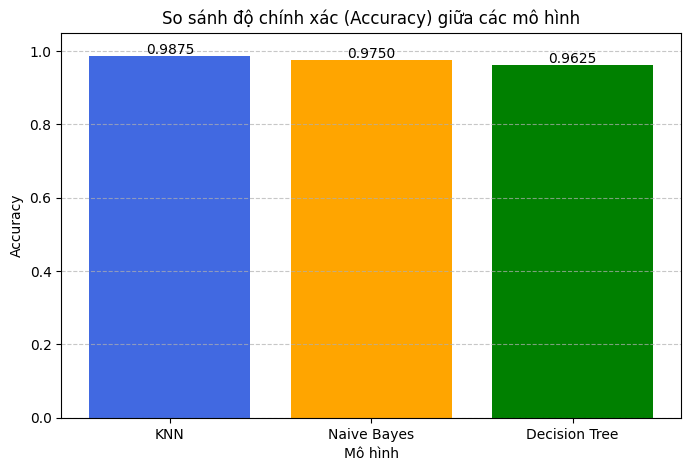

In [266]:
import matplotlib.pyplot as plt

df_plot = df_results.sort_values(by='Accuracy', ascending=False)
colors = ['royalblue', 'orange', 'green']

plt.figure(figsize=(8, 5))

bars = plt.bar(
    df_plot['Model'],
    df_plot['Accuracy'],
    color=colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f'{height:.4f}',
        ha='center',
        fontsize=10
    )

plt.title('So sánh độ chính xác (Accuracy) giữa các mô hình')
plt.xlabel('Mô hình')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

CELL 8: Chọn mô hình tốt nhất

In [267]:
best_name = df_results.iloc[0]['Model']
best_model = models[best_name]

print(f"Mô hình tốt nhất: {best_name}")

Mô hình tốt nhất: KNN


CELL 9: Classification Report (Báo cáo phân loại)

In [268]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test_scaled)

print("\n=== CLASSIFICATION REPORT TRÊN TẬP TEST ===")

print(classification_report(
    y_test,
    y_pred,
    target_names=['Not CKD', 'CKD']
))


=== CLASSIFICATION REPORT TRÊN TẬP TEST ===
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



CELL 10: Confusion Matrix (Ma trận nhầm lẫn)

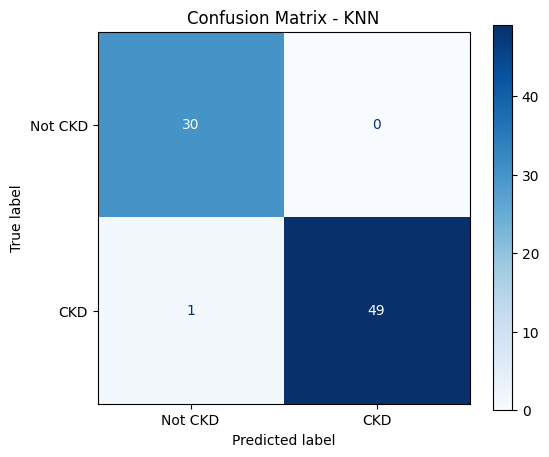

In [269]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not CKD', 'CKD']
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(cmap='Blues', ax=ax)

plt.title(f"Confusion Matrix - {best_name}")

plt.show()

CELL 11: Đánh giá chi tiết trên Test

In [270]:
from sklearn.metrics import accuracy_score

print("ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...")
y_pred = best_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)

print("-" * 40)
print(f"Độ chính xác trên tập Test : {test_acc*100:.2f}%")
print("-" * 40)

ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...
----------------------------------------
Độ chính xác trên tập Test : 98.75%
----------------------------------------


CELL 12: Biểu đồ Learning Curve

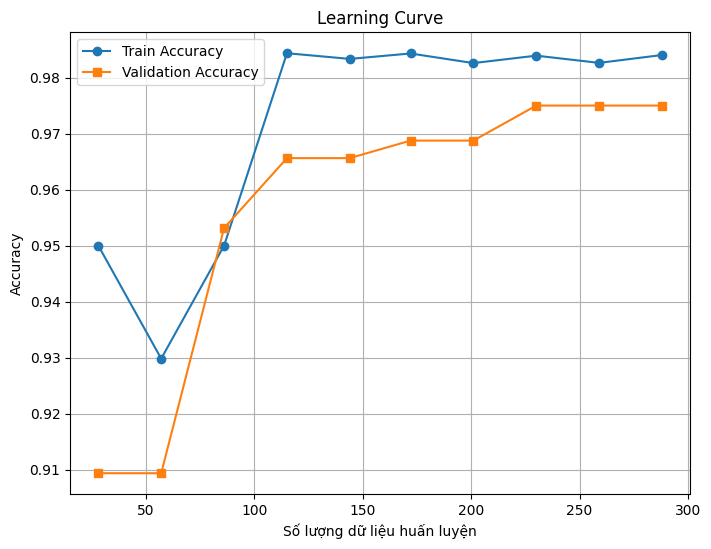

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

learning_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', best_model)
])

train_sizes, train_scores, val_scores = learning_curve(
    learning_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='s',
    label='Validation Accuracy'
)

plt.title('Learning Curve')
plt.xlabel('Số lượng dữ liệu huấn luyện')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

CELL 13: Thử nghiệm dự đoán trên 1 bệnh nhân

In [272]:
import pandas as pd

sample_data_ckd = {
    'age': 52.0,
    'blood_pressure': 90.0,
    'specific_gravity': 1.015,
    'albumin': 4.0,
    'sugar': 0.0,
    'red_blood_cells': 1.0,
    'pus_cell': 0.0,
    'pus_cell_clumps': 0.0,
    'bacteria': 0.0,
    'blood_glucose_random': 223.5,
    'blood_urea': 113.875,
    'serum_creatinine': 5.4625,
    'sodium': 133.0,
    'potassium': 6.0,
    'hemoglobin': 8.1,
    'packed_cell_volume': 23.0,
    'white_blood_cell_count': 5000.0,
    'red_blood_cell_count': 3.6,
    'hypertension': 1.0,
    'diabetes_mellitus': 1.0,
    'coronary_artery_disease': 0.0,
    'appetite': 1.0,
    'pedal_edema': 0.0,
    'anemia': 1.0
}

sample_df = pd.DataFrame([sample_data_ckd])

sample_df = sample_df[X_train.columns]

sample_scaled = scaler.transform(sample_df)

prediction = best_model.predict(sample_scaled)[0]
probabilities = best_model.predict_proba(sample_scaled)[0]

labels = {0: 'Không bệnh thận (Not CKD)', 1: 'Có bệnh thận (CKD)'}

print("=" * 55)
print("KẾT QUẢ DỰ ĐOÁN BỆNH THẬN")
print("=" * 55)
print(f"\nDự đoán: {labels[prediction]}")
print("\nĐỘ TIN CẬY DỰ ĐOÁN:")
print(f"Không bệnh thận: {probabilities[0]*100:.2f}%")
print(f"Có bệnh thận   : {probabilities[1]*100:.2f}%")

true_label = 1  

print("\nNHÃN THỰC TẾ:")
print(labels[true_label])

print("\nĐÁNH GIÁ:")
if prediction == true_label:
    print("✓ Mô hình dự đoán ĐÚNG")
else:
    print("✗ Mô hình dự đoán SAI")

KẾT QUẢ DỰ ĐOÁN BỆNH THẬN

Dự đoán: Có bệnh thận (CKD)

ĐỘ TIN CẬY DỰ ĐOÁN:
Không bệnh thận: 0.00%
Có bệnh thận   : 100.00%

NHÃN THỰC TẾ:
Có bệnh thận (CKD)

ĐÁNH GIÁ:
✓ Mô hình dự đoán ĐÚNG


CELL 14: Lưu mô hình

In [273]:
import os
import joblib
from sklearn.pipeline import Pipeline

inference_pipeline = Pipeline([
    ('scaler', scaler),
    ('classifier', best_model)
])

os.makedirs(r'D:\Kidney-Disease-Prediction\models', exist_ok=True)
model_path = r'D:\Kidney-Disease-Prediction\models\model.pkl'

joblib.dump(inference_pipeline, model_path)

['D:\\Kidney-Disease-Prediction\\models\\model.pkl']